In [2]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.datasets import fetch_california_housing
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
housing = fetch_california_housing(as_frame=True)
df = housing.frame

In [3]:

print(df.shape)
df.head()

(20640, 9)


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


In [4]:
df.info()

df.describe()


<class 'pandas.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   MedInc       20640 non-null  float64
 1   HouseAge     20640 non-null  float64
 2   AveRooms     20640 non-null  float64
 3   AveBedrms    20640 non-null  float64
 4   Population   20640 non-null  float64
 5   AveOccup     20640 non-null  float64
 6   Latitude     20640 non-null  float64
 7   Longitude    20640 non-null  float64
 8   MedHouseVal  20640 non-null  float64
dtypes: float64(9)
memory usage: 1.4 MB


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
count,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,3.870671,28.639486,5.429000,1.096675,1425.476744,3.070655,35.631861,-119.569704,2.068558
std,1.899822,12.585558,2.474173,0.473911,1132.462122,10.386050,2.135952,2.003532,1.153956
min,0.499900,1.000000,0.846154,0.333333,3.000000,0.692308,32.540000,-124.350000,0.149990
25%,2.563400,18.000000,4.440716,1.006079,787.000000,2.429741,33.930000,-121.800000,1.196000
50%,3.534800,29.000000,5.229129,1.048780,1166.000000,2.818116,34.260000,-118.490000,1.797000
75%,4.743250,37.000000,6.052381,1.099526,1725.000000,3.282261,37.710000,-118.010000,2.647250
max,15.000100,52.000000,141.909091,34.066667,35682.000000,1243.333333,41.950000,-114.310000,5.000010


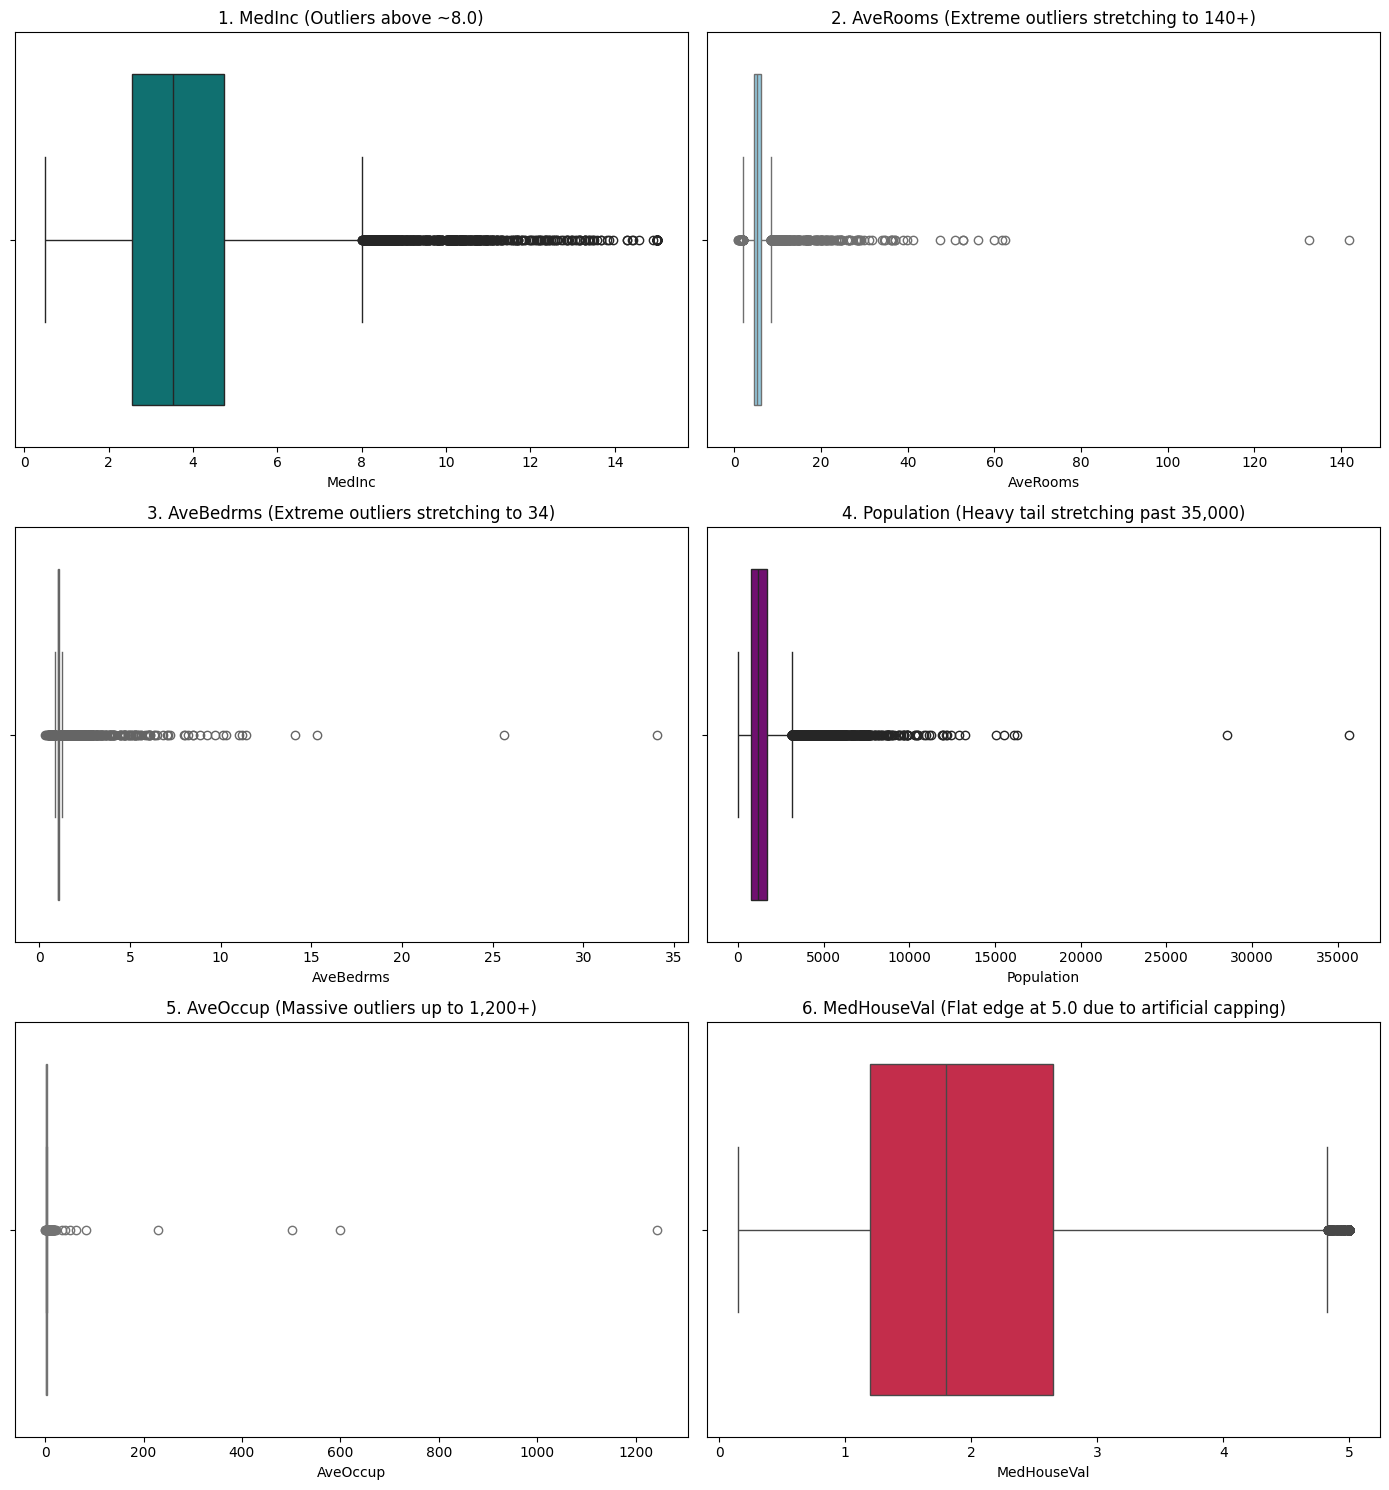

In [5]:
# Set up a 3x2 grid to display all 6 features together
fig, axes = plt.subplots(3, 2, figsize=(14, 15))

# 1. Median Income
sns.boxplot(data=df, x="MedInc", ax=axes[0, 0], color="teal")
axes[0, 0].set_title("1. MedInc (Outliers above ~8.0)")

# 2. Average Rooms
sns.boxplot(data=df, x="AveRooms", ax=axes[0, 1], color="skyblue")
axes[0, 1].set_title("2. AveRooms (Extreme outliers stretching to 140+)")

# 3. Average Bedrooms
sns.boxplot(data=df, x="AveBedrms", ax=axes[1, 0], color="coral")
axes[1, 0].set_title("3. AveBedrms (Extreme outliers stretching to 34)")

# 4. Population
sns.boxplot(data=df, x="Population", ax=axes[1, 1], color="purple")
axes[1, 1].set_title("4. Population (Heavy tail stretching past 35,000)")

# 5. Average Occupancy
sns.boxplot(data=df, x="AveOccup", ax=axes[2, 0], color="lightgreen")
axes[2, 0].set_title("5. AveOccup (Massive outliers up to 1,200+)")

# 6. Median House Value (Target Variable)
sns.boxplot(data=df, x="MedHouseVal", ax=axes[2, 1], color="crimson")
axes[2, 1].set_title("6. MedHouseVal (Flat edge at 5.0 due to artificial capping)")

# Prevent overlapping labels and display the grid
plt.tight_layout()
plt.show()

In [6]:
X = df.drop(columns=["MedHouseVal"])
y = df["MedHouseVal"]

In [7]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

In [8]:
corr_matrix = X_train.corr()

# check highly correlated features
corr_matrix

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude
MedInc,1.000000,-0.121711,0.336013,-0.072550,0.004122,0.022061,-0.076571,-0.017040
HouseAge,-0.121711,1.000000,-0.160892,-0.087983,-0.292283,0.016245,0.005296,-0.101818
AveRooms,0.336013,-0.160892,1.000000,0.836163,-0.073733,-0.004922,0.110695,-0.029339
AveBedrms,-0.072550,-0.087983,0.836163,1.000000,-0.071267,-0.006035,0.073161,0.016647
Population,0.004122,-0.292283,-0.073733,-0.071267,1.000000,0.072330,-0.102499,0.094276
AveOccup,0.022061,0.016245,-0.004922,-0.006035,0.072330,1.000000,0.005837,-0.000598
Latitude,-0.076571,0.005296,0.110695,0.073161,-0.102499,0.005837,1.000000,-0.924485
Longitude,-0.017040,-0.101818,-0.029339,0.016647,0.094276,-0.000598,-0.924485,1.000000


In [9]:
# Feature engineering after split
X_train["Bedrm_Ratio"] = X_train["AveBedrms"] / X_train["AveRooms"]
X_test["Bedrm_Ratio"] = X_test["AveBedrms"] / X_test["AveRooms"]

sf_coords = (37.7749, -122.4194)
la_coords = (34.0522, -118.2437)

X_train["Dist_to_SF"] = np.sqrt(
    (X_train["Latitude"] - sf_coords[0])**2 +
    (X_train["Longitude"] - sf_coords[1])**2
)

X_test["Dist_to_SF"] = np.sqrt(
    (X_test["Latitude"] - sf_coords[0])**2 +
    (X_test["Longitude"] - sf_coords[1])**2
)

X_train["Dist_to_LA"] = np.sqrt(
    (X_train["Latitude"] - la_coords[0])**2 +
    (X_train["Longitude"] - la_coords[1])**2
)

X_test["Dist_to_LA"] = np.sqrt(
    (X_test["Latitude"] - la_coords[0])**2 +
    (X_test["Longitude"] - la_coords[1])**2
)

# Now drop columns you replaced
cols_to_drop = ["AveBedrms", "Latitude", "Longitude"]

X_train = X_train.drop(columns=cols_to_drop)
X_test = X_test.drop(columns=cols_to_drop)

In [10]:
y_mean = y_train.mean()

y_pred_baseline = [y_mean] * len(y_test)


In [11]:
from sklearn.metrics import root_mean_squared_error
baseline_rmse = root_mean_squared_error(
    y_test,
    y_pred_baseline
)

print(baseline_rmse)

1.1448563543099792


In [12]:
from sklearn.linear_model import LinearRegression

lr_model = LinearRegression()

lr_model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [13]:
y_pred_lr = lr_model.predict(X_test)

In [14]:
from sklearn.metrics import (
    mean_absolute_error,
    r2_score,
    root_mean_squared_error
)

mae = mean_absolute_error(y_test, y_pred_lr)

rmse = root_mean_squared_error(y_test, y_pred_lr)

r2 = r2_score(y_test, y_pred_lr)

print(mae)
print(rmse)
print(r2)

0.5625055038115754
0.7743431519710698
0.5424273437065368


In [15]:
train_rmse = root_mean_squared_error(
    y_train,
    lr_model.predict(X_train)
)

test_rmse = root_mean_squared_error(
    y_test,
    y_pred_lr
)

print(train_rmse)
print(test_rmse)

0.7604403316918599
0.7743431519710698


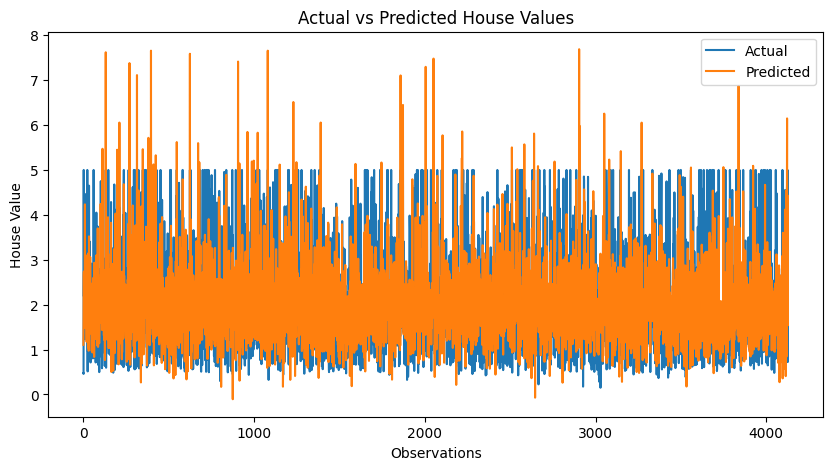

In [16]:
plt.figure(figsize=(10, 5))

plt.plot(y_test.values, label="Actual")
plt.plot(y_pred_lr, label="Predicted")

plt.title("Actual vs Predicted House Values")
plt.xlabel("Observations")
plt.ylabel("House Value")
plt.legend()

plt.show()

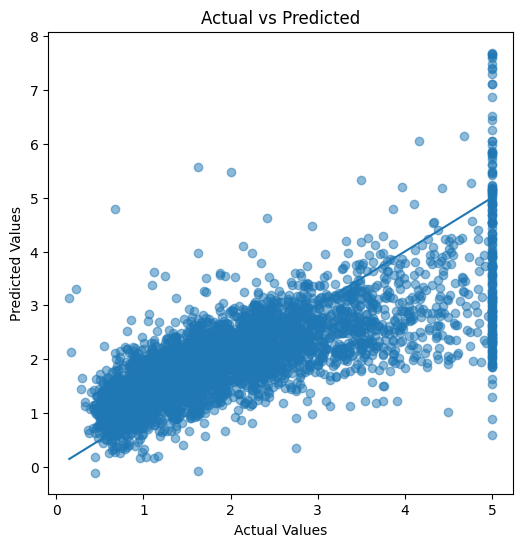

In [17]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,6))

plt.scatter(y_test, y_pred_lr, alpha=0.5)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
)

plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.title("Actual vs Predicted")

plt.show()

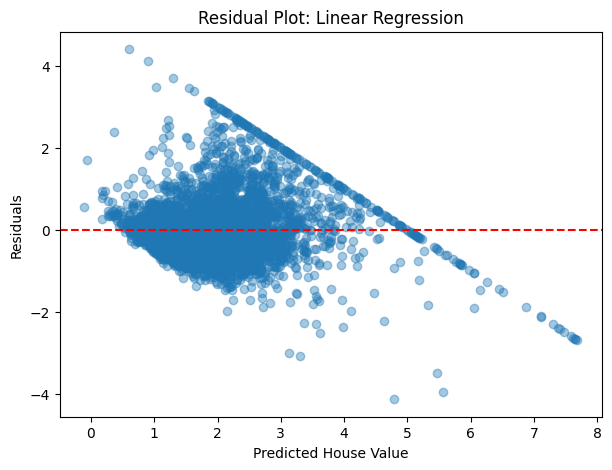

In [18]:
# Predict with Linear Regression
y_pred_lr = lr_model.predict(X_test)   # use this if you trained LR with scaled data

# Calculate residuals
lr_residuals = y_test - y_pred_lr

# Plot residuals
plt.figure(figsize=(7, 5))

plt.scatter(y_pred_lr, lr_residuals, alpha=0.4)
plt.axhline(y=0, color="red", linestyle="--")

plt.xlabel("Predicted House Value")
plt.ylabel("Residuals")
plt.title("Residual Plot: Linear Regression")

plt.show()

In [19]:
print("Intercept:", lr_model.intercept_)

Intercept: -0.6397862379028805


In [20]:
coef_df = pd.DataFrame({
    "Feature": X_train.columns,
    "Coefficient": lr_model.coef_
})

coef_df

,Feature,Coefficient
0,MedInc,0.503144
1,HouseAge,0.013702
2,AveRooms,0.010863
3,Population,0.000006
4,AveOccup,-0.004381
5,Bedrm_Ratio,4.713060
6,Dist_to_SF,-0.103610
7,Dist_to_LA,-0.108885


### RIDGE 

In [21]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)

In [22]:
from sklearn.linear_model import RidgeCV

ridge = RidgeCV(
    alphas=[0.01, 0.1, 1, 10, 100]
)

ridge.fit(
    X_train_scaled,
    y_train
)

,"alphas alphas: array-like of shape (n_alphas,), default=(0.1, 1.0, 10.0)Array of alpha values to try.Regularization strength; must be a positive float. Regularizationimproves the conditioning of the problem and reduces the variance ofthe estimates. Larger values specify stronger regularization.Alpha corresponds to ``1 / (2C)`` in other linear models such as:class:`~sklearn.linear_model.LogisticRegression` or:class:`~sklearn.svm.LinearSVC`.If using Leave-One-Out cross-validation, alphas must be strictly positive.","[0.01, 0.1, ...]"
,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto false, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"scoring scoring: str, callable, default=NoneThe scoring method to use for cross-validation. Options:- str: see :ref:`scoring_string_names` for options.- callable: a scorer callable object (e.g., function) with signature ``scorer(estimator, X, y)``. See :ref:`scoring_callable` for details.- `None`: negative :ref:`mean squared error ` if cv is None (i.e. when using leave-one-out cross-validation), or :ref:`coefficient of determination ` (:math:`R^2`) otherwise.",None
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the efficient Leave-One-Out cross-validation- integer, to specify the number of folds.- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if ``y`` is binary or multiclass,:class:`~sklearn.model_selection.StratifiedKFold` is used, else,:class:`~sklearn.model_selection.KFold` is used.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here.",None
,"gcv_mode gcv_mode: {'auto', 'svd', 'eigen'}, default='auto'Flag indicating which strategy to use when performingLeave-One-Out Cross-Validation. Options are:: 'auto' : use 'svd' if n_samples > n_features, otherwise use 'eigen' 'svd' : force use of singular value decomposition of X when X is dense, eigenvalue decomposition of X^T.X when X is sparse. 'eigen' : force computation via eigendecomposition of X.X^TThe 'auto' mode is the default and is intended to pick the cheaperoption of the two depending on the shape of the training data.",None
,"store_cv_results store_cv_results: bool, default=FalseFlag indicating if the cross-validation values corresponding toeach alpha should be stored in the ``cv_results_`` attribute (seebelow). This flag is only compatible with ``cv=None`` (i.e. usingLeave-One-Out Cross-Validation)... versionchanged:: 1.5 Parameter name changed from `store_cv_values` to `store_cv_results`.",False
,"alpha_per_target alpha_per_target: bool, default=FalseFlag indicating whether to optimize the alpha value (picked from the`alphas` parameter list) for each target separately (for multi-outputsettings: multiple prediction targets). When set to `True`, afterfitting, the `alpha_` attribute will contain a value for each target.When set to `False`, a single alpha is used for all targets... versionadded:: 0.24",False


In [23]:
from sklearn.metrics import (
    mean_absolute_error,
    root_mean_squared_error,
    r2_score
)

ridge_pred = ridge.predict(X_test_scaled)

ridge_mae = mean_absolute_error(
    y_test,
    ridge_pred
)

ridge_rmse = root_mean_squared_error(
    y_test,
    ridge_pred
)
ridge_r2 = r2_score(
    y_test,
    ridge_pred
)

print(ridge_mae)
print(ridge_rmse)
print(ridge_r2)

print("Best Alpha:", ridge.alpha_)

0.5625352197992121
0.7743102620714569
0.5424662132931841
Best Alpha: 10.0


### LASSO

In [24]:
from sklearn.linear_model import LassoCV

lasso = LassoCV(
    cv=5,
    random_state=42
)

lasso.fit(
    X_train_scaled,
    y_train
)

,"eps eps: float, default=1e-3Length of the path. ``eps=1e-3`` means that``alpha_min / alpha_max = 1e-3``.",0.001
,"n_alphas n_alphas: int, default=100Number of alphas along the regularization path... deprecated:: 1.7 `n_alphas` was deprecated in 1.7 and will be removed in 1.9. Use `alphas` instead.",'deprecated'
,"alphas alphas: array-like or int, default=NoneValues of alphas to test along the regularization path.If int, `alphas` values are generated automatically.If array-like, list of alpha values to use... versionchanged:: 1.7 `alphas` accepts an integer value which removes the need to pass `n_alphas`... deprecated:: 1.7 `alphas=None` was deprecated in 1.7 and will be removed in 1.9, at which point the default value will be set to 100.",'warn'
,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto false, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"precompute precompute: 'auto', bool or array-like of shape (n_features, n_features), default='auto'Whether to use a precomputed Gram matrix to speed upcalculations. If set to ``'auto'`` let us decide. The Grammatrix can also be passed as argument.",'auto'
,"max_iter max_iter: int, default=1000The maximum number of iterations.",1000
,"tol tol: float, default=1e-4The tolerance for the optimization: if the updates are smaller or equal to``tol``, the optimization code checks the dual gap for optimality and continuesuntil it is smaller or equal to ``tol``.",0.0001
,"copy_X copy_X: bool, default=TrueIf ``True``, X will be copied; else, it may be overwritten.",True
,"cv cv: int, cross-validation generator or iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross-validation,- int, to specify the number of folds.- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For int/None inputs, :class:`~sklearn.model_selection.KFold` is used.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: bool or int, default=FalseAmount of verbosity.",False
,"n_jobs n_jobs: int, default=NoneNumber of CPUs to use during the cross validation.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.",None


In [25]:
lasso_pred = lasso.predict(X_test_scaled)

lasso_mae = mean_absolute_error(
    y_test,
    lasso_pred
)

lasso_rmse = root_mean_squared_error(
    y_test,
    lasso_pred
)

lasso_r2 = r2_score(
    y_test,
    lasso_pred
)

print(lasso_mae)
print(lasso_rmse)
print(lasso_r2)

print("Best Alpha:", lasso.alpha_)

0.5624375154095532
0.7742199101604093
0.5425729835173655
Best Alpha: 0.0007985195644260351


In [26]:
results = pd.DataFrame({
    "Model": [
        "Linear Regression",
        "Ridge",
        "Lasso"
    ],
    "MAE": [
        mae,
        ridge_mae,
        lasso_mae
    ],
    "RMSE": [
        rmse,
        ridge_rmse,
        lasso_rmse
    ],
    "R2": [
        r2,
        ridge_r2,
        lasso_r2
    ]
})

print(results)

               Model       MAE      RMSE        R2
0  Linear Regression  0.562506  0.774343  0.542427
1              Ridge  0.562535  0.774310  0.542466
2              Lasso  0.562438  0.774220  0.542573


In [27]:
coef_df = pd.DataFrame({
    "Feature": X_train.columns,
    "Coefficient": lr_model.coef_
})

coef_df["Abs_Coefficient"] = coef_df["Coefficient"].abs()

coef_df.sort_values(
    "Abs_Coefficient",
    ascending=False
)

,Feature,Coefficient,Abs_Coefficient
5,Bedrm_Ratio,4.713060,4.713060
0,MedInc,0.503144,0.503144
7,Dist_to_LA,-0.108885,0.108885
6,Dist_to_SF,-0.103610,0.103610
1,HouseAge,0.013702,0.013702
2,AveRooms,0.010863,0.010863
4,AveOccup,-0.004381,0.004381
3,Population,0.000006,0.000006
